# Linear heat conduction problem with different materials, with full order and reduced order simulations.

![Problem Schematic](problem_schematics.png)


## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib
import sci_mplstyle_package

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.utils.visualization.color_palette import set_color_palette
import skrom.problem_classes.masterclass as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

PETSc available: True


### Plot Properties

In [ ]:
import sci_mplstyle_package
set_color_palette();

In [9]:
generate_data = True
visualize = True
run_svd = True
run_rom = True
rom_report = True

## Full Order Simulation

In [5]:
# Conditional execution block for simulation data generation
if generate_data:
    # Create an instance of the linear heat conduction simulation
    sim =  master.fom_simulation()

    sim.run_simulation()

Snap 1/64 params=[4.52033043e-01 6.27125869e+02]
Snap 2/64 params=[  -3.1561909  -918.45355742]
Snap 3/64 params=[ -0.64370438 302.52434872]
Snap 4/64 params=[  3.93966097 -26.95726044]
Snap 5/64 params=[ 2.78512016 82.34366775]
Snap 6/64 params=[  -1.61221236 -369.15481836]
Snap 7/64 params=[ -2.12323176 972.36775979]
Snap 8/64 params=[   1.29602513 -701.07271895]
Snap 9/64 params=[  1.596391   499.53601882]
Snap 10/64 params=[  -2.8004344 -204.9102895]
Snap 11/64 params=[ -1.31196094 570.6935972 ]
Snap 12/64 params=[   2.10780308 -849.79905933]
Snap 13/64 params=[  3.1402706  790.99631868]
Snap 14/64 params=[-4.67477225e-01 -5.07479401e+02]
Snap 15/64 params=[ -3.95546684 154.41622771]
Snap 16/64 params=[   0.62837464 -422.16908745]
Snap 17/64 params=[  0.93926359 192.39042141]
Snap 18/64 params=[  -3.64147594 -479.8112046 ]
Snap 19/64 params=[-1.5237686e-01  8.6219894e+02]
Snap 20/64 params=[   3.4502942  -590.53839929]
Snap 21/64 params=[  2.29379693 519.03271675]
Snap 22/64 params

### Load Simulation Data

In [6]:
# #Load the ROM_data
# current_dir = Path().resolve()
# rom_dir = current_dir / "ROM_data"
# fos_solutions, sim_data = load_rom_data(self = None, rom_data_dir=rom_dir)

# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\static\linear\problem_2\ROM_data


### Generate training solution dataset

In [ ]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = rom_data.param_list

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


64


### Training Solution Snapshots

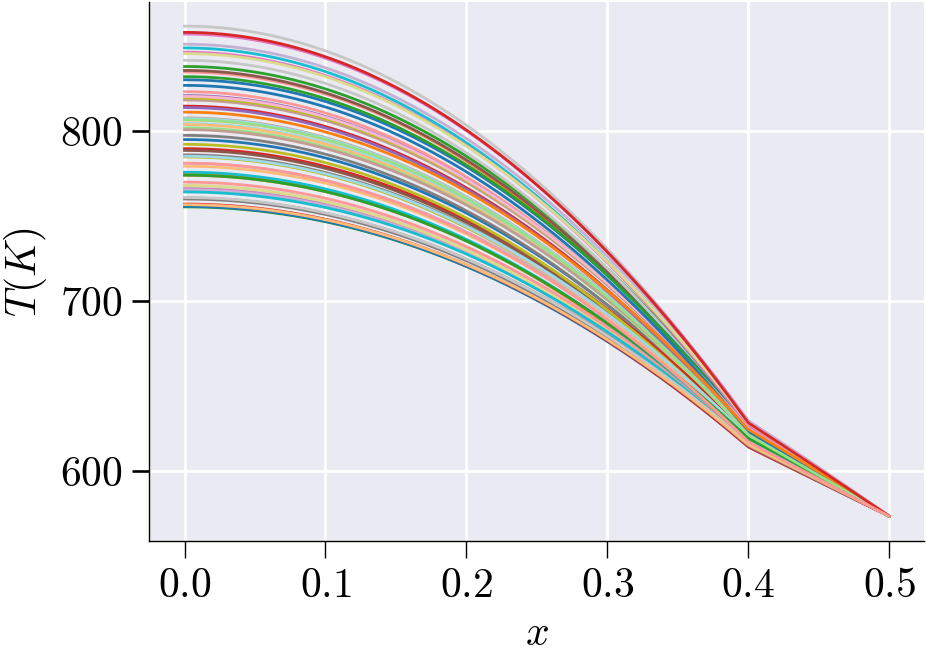

In [10]:
if visualize:
    # Plot the computed temperature distribution
    # Create a figure with specified dimensions (5x3.5 inches) for compact visualization
    plt.figure(figsize=(5, 3.5))

    # Extract spatial coordinates from the mesh data
    # The mesh is stored as an object in rom_data
    # mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
    mesh_domain = rom_data.mesh.p[0]

    # Plot temperature profiles for all parameter combinations
    # Loop through all non-linear solutions (each row is a complete temperature field)
    for j in range(len(LS)):
        # Plot each temperature distribution as a line
        # x-axis: spatial coordinates from the mesh
        # y-axis: temperature values at each spatial location
        # '-' specifies solid line style, markersize affects any markers
        plt.plot(mesh_domain, LS[j], '-', markersize=2)

    # Set axis labels with proper mathematical notation
    plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
    plt.ylabel("$T (K)$")    # Temperature in Kelvin (LaTeX formatting)

    # Display the plot
    plt.show()

### Mean Subtraction

In [11]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Distribution of training parameters

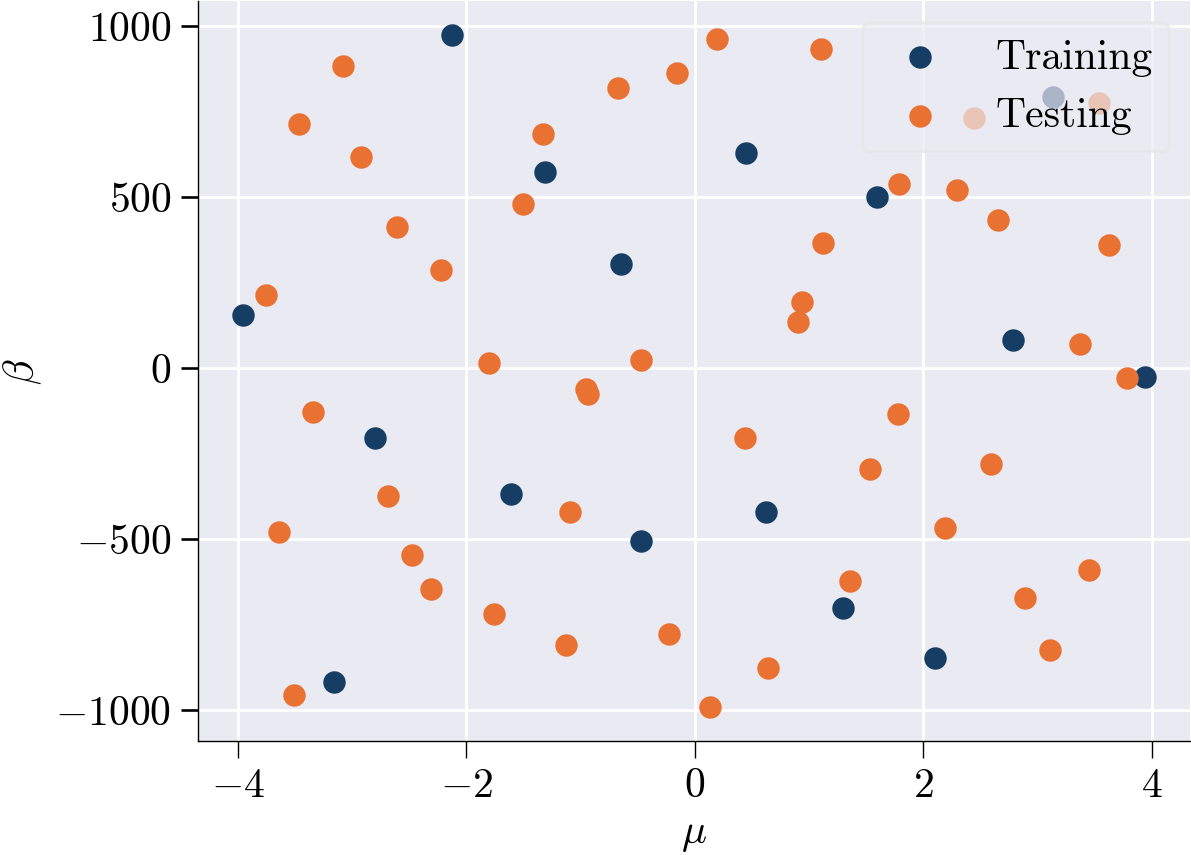

In [12]:
if visualize:
    # Visualize the parameter space distribution for training and testing data
    # Plot training parameter combinations (first 16 samples)
    # Extract first and second parameter columns for 2D visualization
    plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
            param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
            s=50,                      # Marker size
            c='#163e64',              # Dark blue color for training points
            label="Training")         # Legend label

    # Plot testing parameter combinations (samples 17 and beyond)
    plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
            param_list[16:][:, 1],     # Second parameter (β) for testing samples
            s=50,                      # Marker size (same as training)
            c='#e97132',              # Orange color for testing points
            label="Testing")          # Legend label

    # Set axis labels using LaTeX formatting for mathematical notation
    plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
    plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

    # Add legend to distinguish between training and testing sets
    plt.legend()

    #See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 4


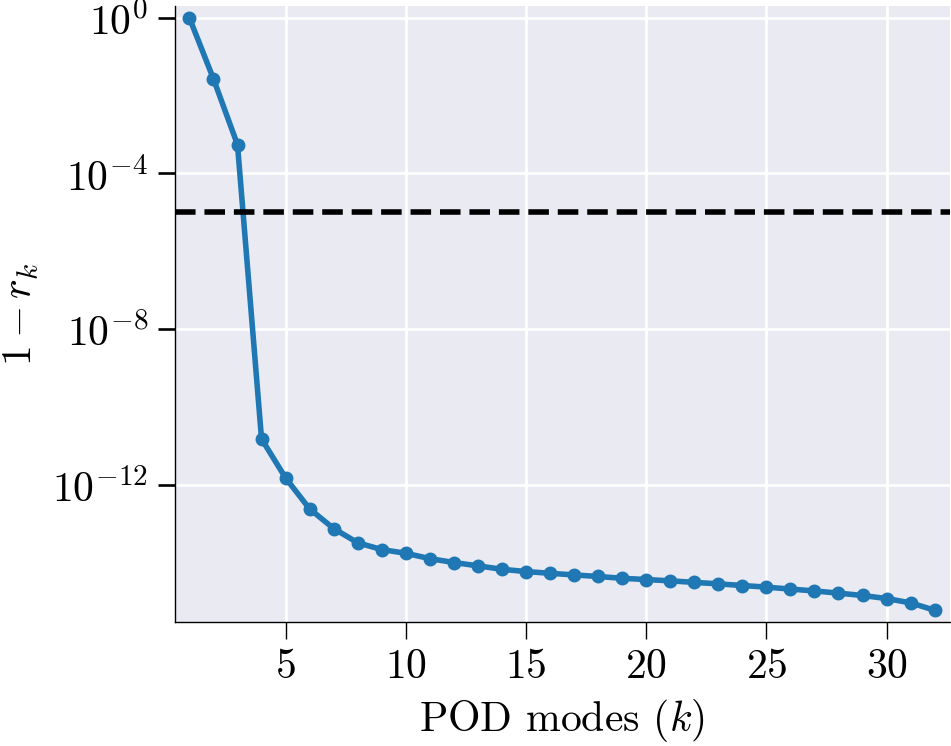

In [13]:
if run_svd:
    # fig, ax = plt.subplots(figsize=(5,3.5))
    plt.rcParams['lines.markersize'] = 6
    plt.rcParams['lines.linewidth'] = 2.0

    n_sel, U = svd_mode_selector(LS_train_ms, tolerance = 1e-5,modes=True)
    n_sel = n_sel + 1
    V_sel = U[:, :n_sel]#This will be passed in my simulation function
    plt.ylabel('$1-r_{k}$')
    plt.xlabel('POD modes ($k$)')

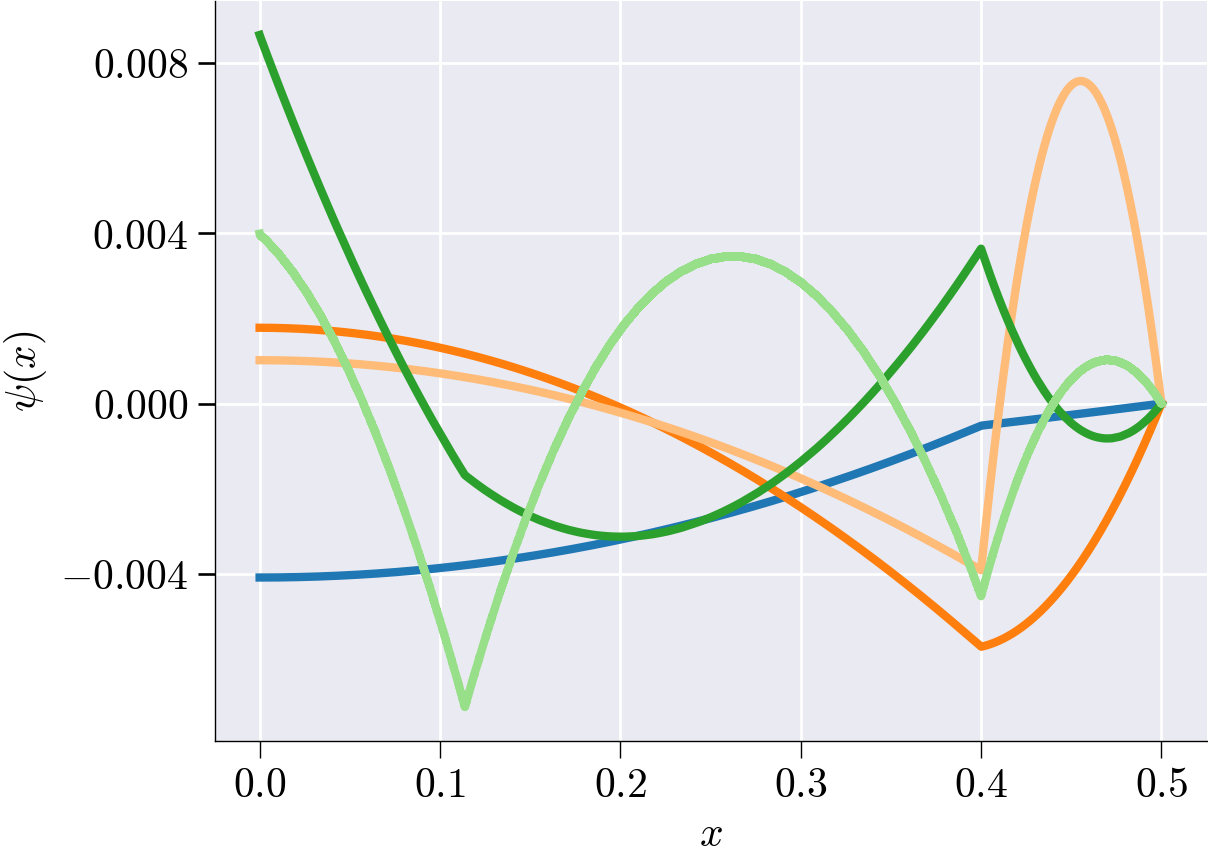

In [15]:
if visualize:
    fig, ax = plt.subplots()

    for i in range(n_sel):
        plt.plot(mesh_domain, V_sel[:,i],lw=3)

    ax.set_xlabel('$x$')
    ax.set_ylabel('$\\psi(x)$')
        
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
    plt.show()

## ROM Simulation

In [ ]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    rom = master.rom_simulation(V_sel=V_sel,train_ref=LS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\static\linear\problem_2\ROM_data


In [17]:
if run_rom:
    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    rom.run_rom_simulation();

Snap 1/32 params=[  0.90372551 134.1767665 ]
Snap 2/32 params=[  -3.50884871 -955.51588014]
Snap 3/32 params=[ -1.32813375 682.73174018]
Snap 4/32 params=[   2.19180227 -468.78583543]
Snap 5/32 params=[  3.54046288 772.37531729]
Snap 6/32 params=[ -0.93461037 -76.16778463]
Snap 7/32 params=[ -2.22268451 285.71384773]
Snap 8/32 params=[   1.35975245 -624.53187443]
Snap 9/32 params=[  1.78928813 536.71146557]
Snap 10/32 params=[  -2.68395514 -373.53830971]
Snap 11/32 params=[-0.47395069 23.36152084]
Snap 12/32 params=[   3.11056063 -825.1780048 ]
Snap 13/32 params=[  2.65258033 431.74595386]
Snap 14/32 params=[  -1.75816201 -719.7761517 ]
Snap 15/32 params=[ -3.0794314  883.17956589]
Snap 16/32 params=[   0.44258089 -206.5099813 ]
Snap 17/32 params=[1.95690572e-01 9.60998463e+02]
Snap 18/32 params=[  -3.33986864 -128.02351266]
Snap 19/32 params=[ -1.50492642 478.95954177]
Snap 20/32 params=[   2.89202482 -673.23013581]
Snap 21/32 params=[ 3.37148378 69.83887218]
Snap 22/32 params=[-2.265

In [ ]:
if rom_report:
    #Assign values for the statistics
    LS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up[1:]
    ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 2.6361e-07
Relative L2 Error:        5.7551e-12
L∞ Error:                 1.9869e-08
Relative L∞ Error:        2.3151e-11
RMSE:                     4.1189e-09
MAE:                      1.9077e-09

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -1.2506e-10
95th Percentile Error:    1.1291e-08

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 9.6573e-14
Max Rel L2 Error over time/parameter: 4.7342e-13
Min Rel L2 Error over time/parameter: 2.8261e-15
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

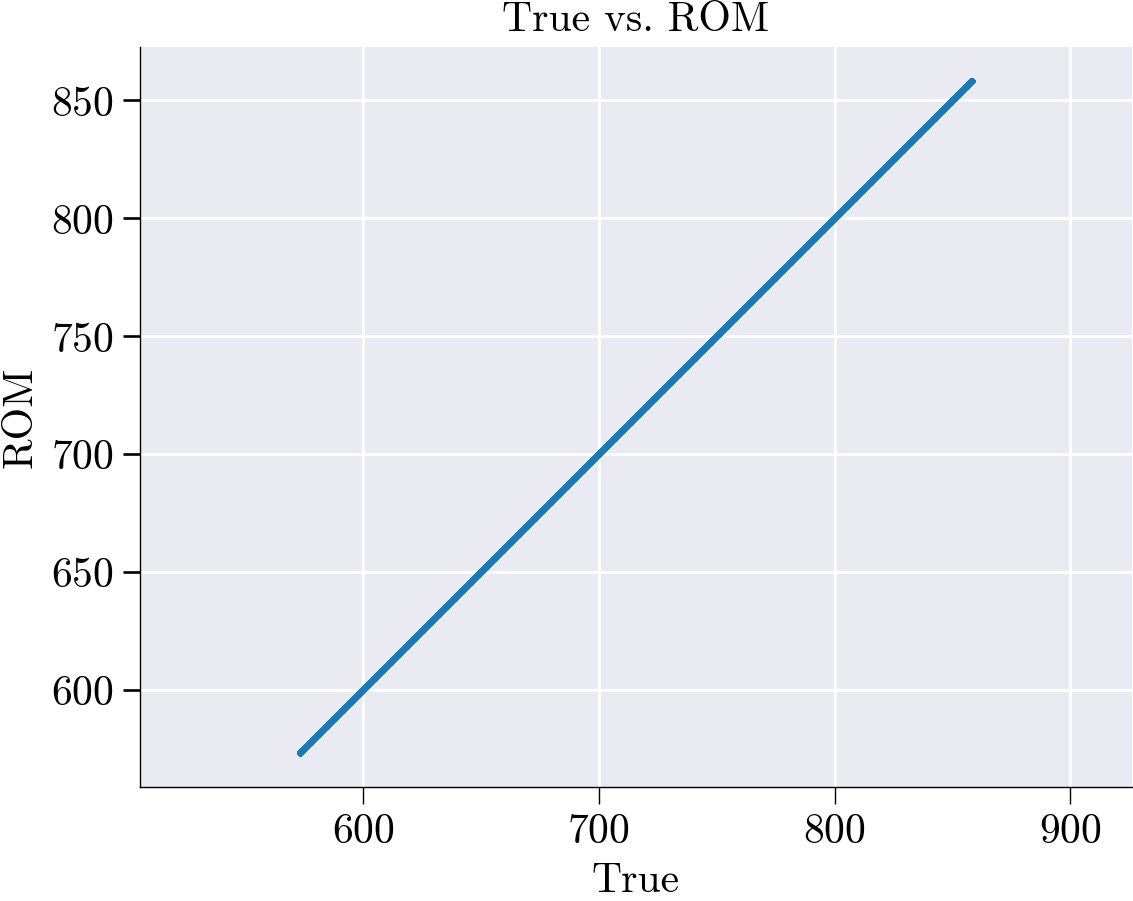

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


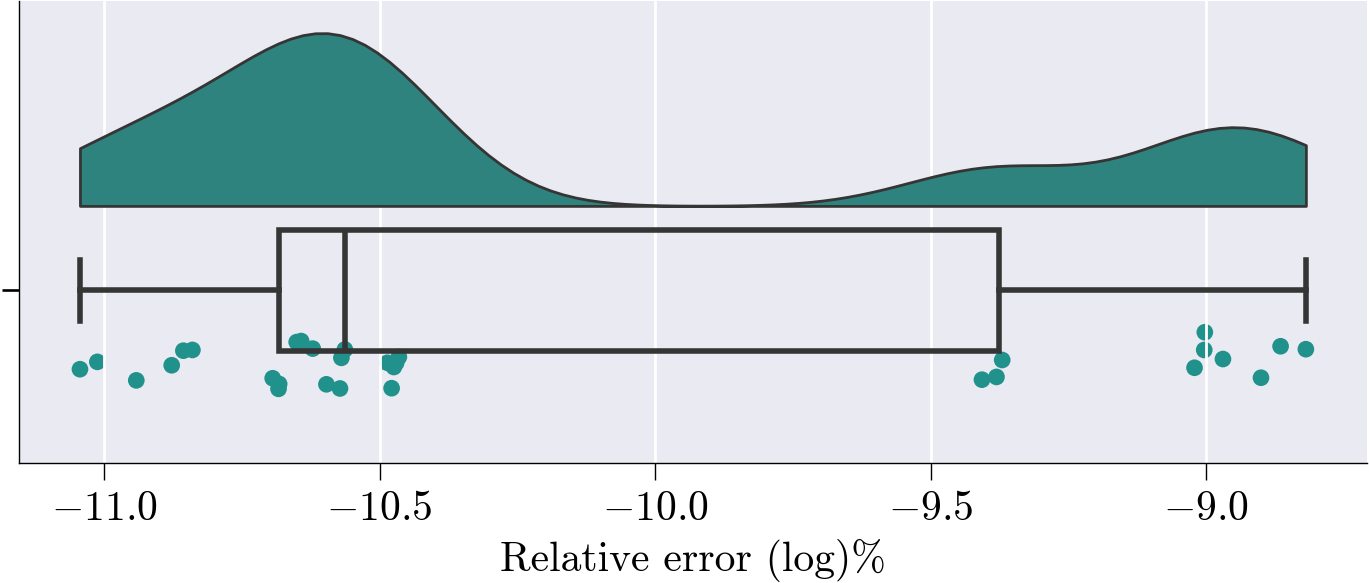

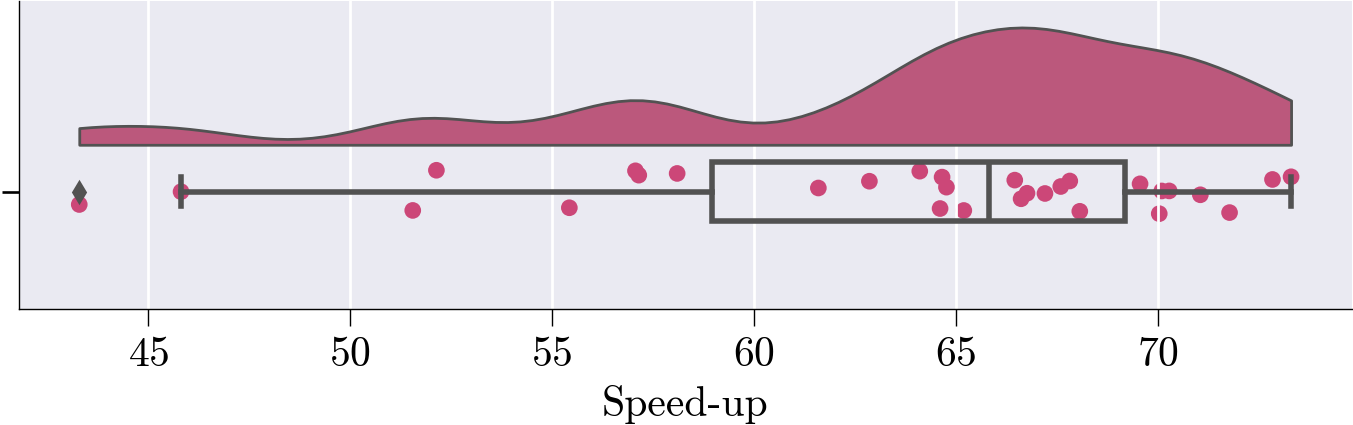

In [20]:
if rom_report:

    # --- ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        LS_test[1:],                   # full-order (true) solution snapshots
        LS_rom[1:],              # hyper-ROM-generated solution snapshots
        ROM_relative_error[1:],   # precomputed relative error of the hyper-ROM
        ROM_speed_up[1:],         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )
